[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/stevalia14/UAS-STATISTIKA/blob/main/Stevalia_Bindi_Rahmania_F5212520040.ipynb)

# Prediksi Angka Harapan Hidup (AHH) Berdasarkan Rata-Rata Lama Sekolah, Pengeluaran Per Kapita, dan Garis Kemiskinan di Provinsi Indonesia Tahun 2019–2023 Menggunakan Regresi Linear Berganda




In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


In [56]:
file_path = "Dataset_AHH_Indonesia.csv"
df = pd.read_csv(file_path)

print("Dataset berhasil dimuat!")

Dataset berhasil dimuat!


#  Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi dataset untuk memahami struktur data, distribusi variabel, dan hubungan antar variabel sebelum membangun model prediksi.

In [57]:
print("=== 5 Data Pertama ===")
df.head()

=== 5 Data Pertama ===


,Provinsi,Tahun,AHH_Y,Rata_Lama_Sekolah_X1,Pengeluaran_Per_Kapita_X2,Garis_Kemiskinan_X3
0,Aceh,2019,69.91,9.59,9603,490593
1,Aceh,2020,69.97,9.71,9492,527168
2,Aceh,2021,70.00,9.77,9572,547406
3,Aceh,2022,70.21,9.79,9963,586078
4,Aceh,2023,70.38,9.89,10334,634890


In [58]:
print("=== Statistik Deskriptif ===")
df.describe()

=== Statistik Deskriptif ===


,Tahun,AHH_Y,Rata_Lama_Sekolah_X1,Pengeluaran_Per_Kapita_X2,Garis_Kemiskinan_X3
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,2021.000000,70.281294,9.150941,10982.147059,524670.717647
std,1.418391,2.480678,0.827634,2216.601457,113502.924348
min,2019.000000,64.870000,6.850000,6954.000000,328410.000000
25%,2020.000000,68.880000,8.515000,9512.000000,439450.250000
50%,2021.000000,70.395000,9.175000,10842.500000,504711.000000
75%,2022.000000,71.757500,9.732500,11839.500000,599936.750000
max,2023.000000,75.220000,11.420000,19373.000000,876340.000000


In [59]:
print("=== Informasi Dataset ===")
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Provinsi                   170 non-null    object 
 1   Tahun                      170 non-null    int64  
 2   AHH_Y                      170 non-null    float64
 3   Rata_Lama_Sekolah_X1       170 non-null    float64
 4   Pengeluaran_Per_Kapita_X2  170 non-null    int64  
 5   Garis_Kemiskinan_X3        170 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 8.1+ KB


In [60]:
print(f"Jumlah baris (observasi) : {df.shape[0]}")
print(f"Jumlah kolom (variabel)  : {df.shape[1]}")
print(f"Jumlah provinsi          : {df['Provinsi'].nunique()}")
print(f"Rentang tahun            : {df['Tahun'].min()} - {df['Tahun'].max()}")

Jumlah baris (observasi) : 170
Jumlah kolom (variabel)  : 6
Jumlah provinsi          : 34
Rentang tahun            : 2019 - 2023


In [61]:
print("=== Jumlah Nilai Kosong per Kolom ===")
print(df.isnull().sum())

=== Jumlah Nilai Kosong per Kolom ===
Provinsi                     0
Tahun                        0
AHH_Y                        0
Rata_Lama_Sekolah_X1         0
Pengeluaran_Per_Kapita_X2    0
Garis_Kemiskinan_X3          0
dtype: int64


In [62]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


==== Deteksi Outlier dengan IQR pada kolom AHH_Y ====
Batas Bawah : 64.56374999999997
Batas Atas  : 76.07375000000002
Jumlah AHH_Y Outlier : 0 baris dari total 170 baris data


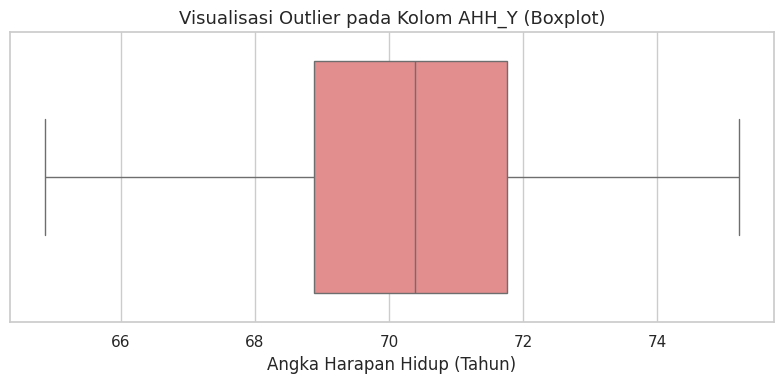

In [63]:
kolom_target = 'AHH_Y'

print(f"==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightcoral')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)', fontsize=13)
plt.xlabel('Angka Harapan Hidup (Tahun)')
plt.tight_layout()
plt.show()

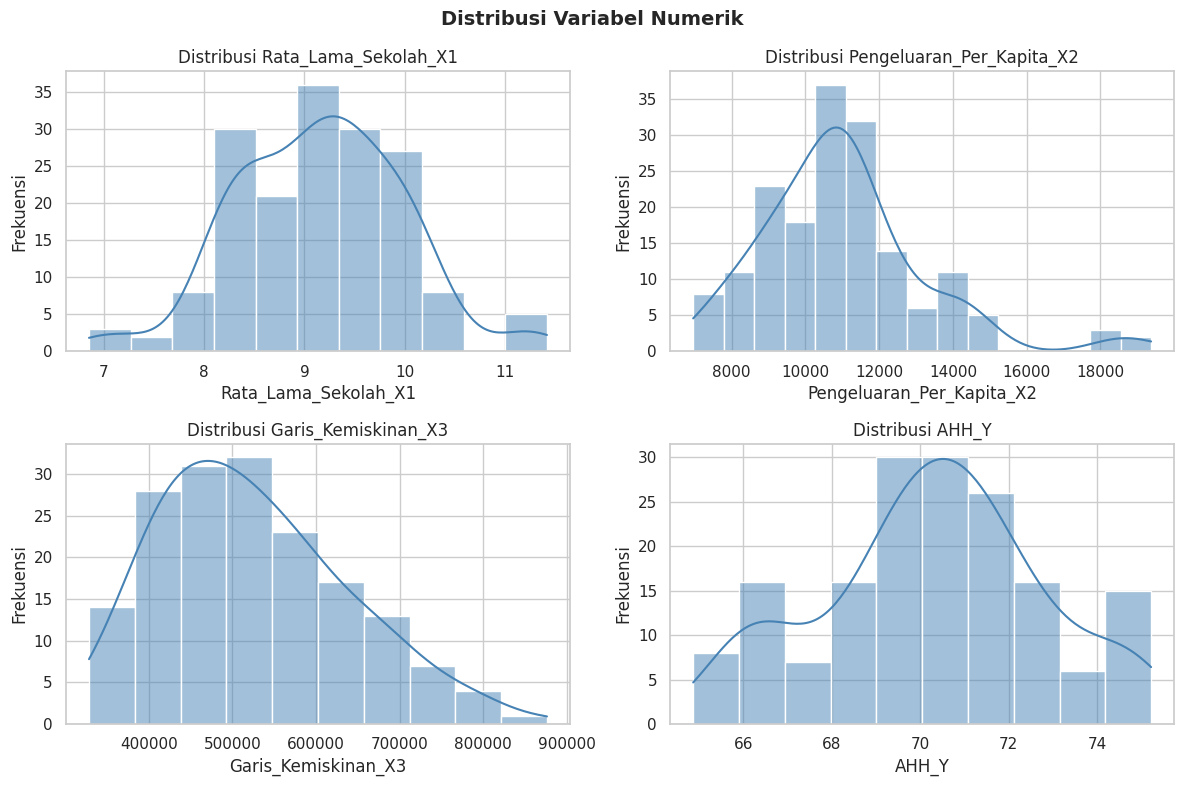

In [64]:
numerik_cols = ['Rata_Lama_Sekolah_X1', 'Pengeluaran_Per_Kapita_X2', 'Garis_Kemiskinan_X3', 'AHH_Y']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), numerik_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

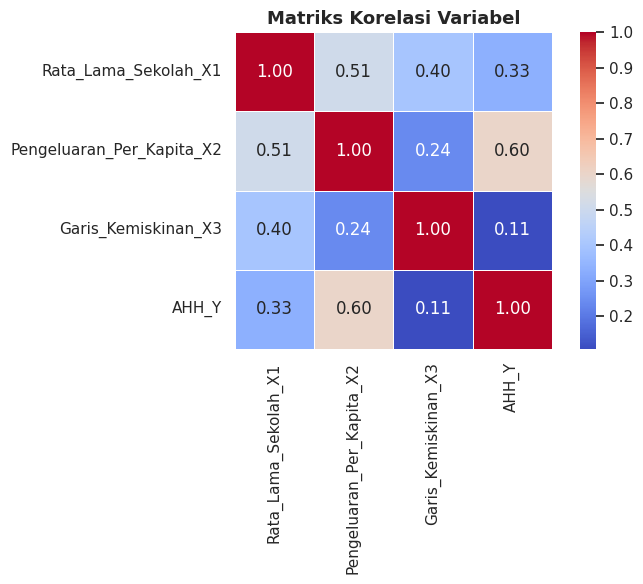


=== Nilai Korelasi terhadap AHH_Y ===
AHH_Y                        1.000000
Pengeluaran_Per_Kapita_X2    0.601408
Rata_Lama_Sekolah_X1         0.332276
Garis_Kemiskinan_X3          0.108064
Name: AHH_Y, dtype: float64


In [65]:
plt.figure(figsize=(8, 6))
corr_matrix = df[numerik_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriks Korelasi Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Nilai Korelasi terhadap AHH_Y ===")
print(corr_matrix['AHH_Y'].sort_values(ascending=False))

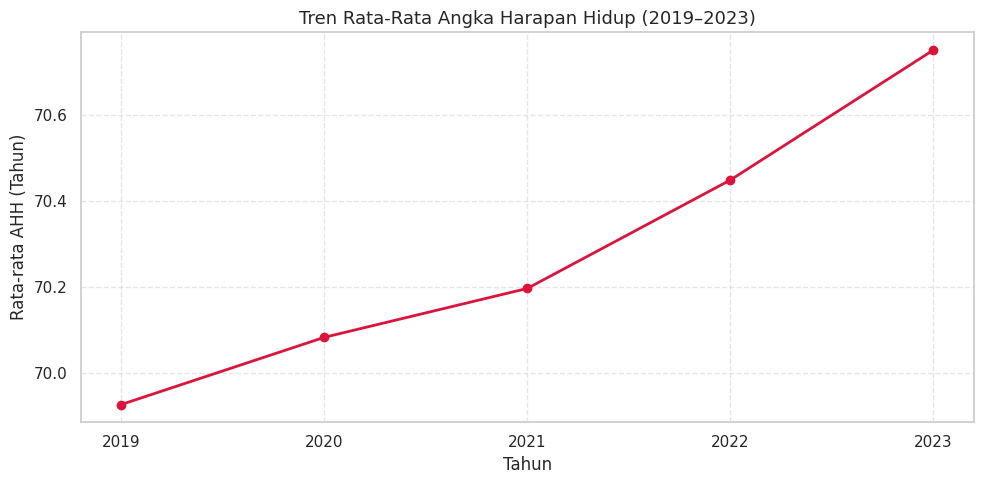

In [66]:
plt.figure(figsize=(10, 5))
trend = df.groupby('Tahun')['AHH_Y'].mean().reset_index()
plt.plot(trend['Tahun'], trend['AHH_Y'], marker='o', color='crimson', linewidth=2)
plt.title('Tren Rata-Rata Angka Harapan Hidup (2019–2023)', fontsize=13)
plt.xlabel('Tahun')
plt.ylabel('Rata-rata AHH (Tahun)')
plt.xticks(trend['Tahun'].astype(int))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

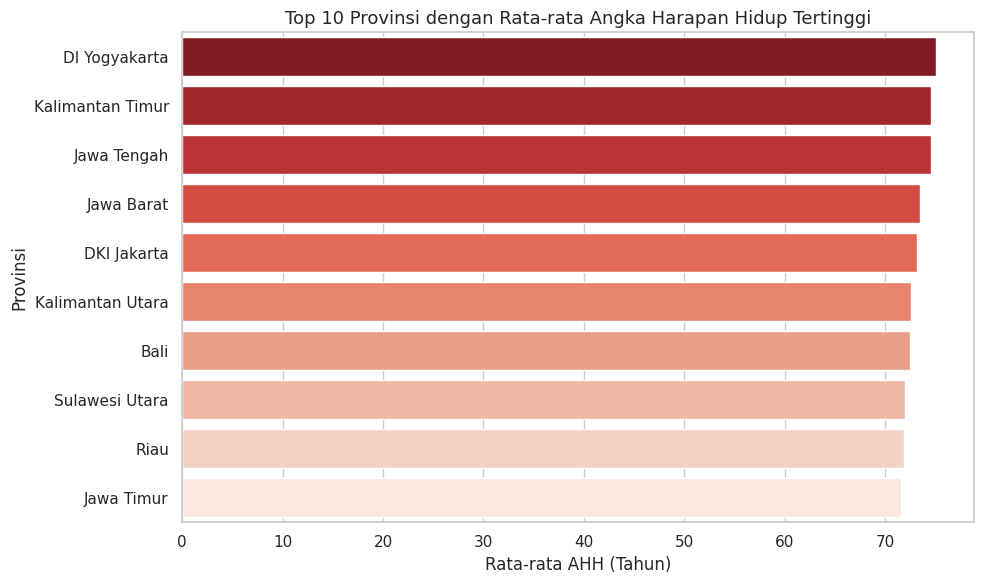

In [67]:
# Top 10 provinsi dengan rata-rata AHH tertinggi
plt.figure(figsize=(10, 6))
top10 = df.groupby('Provinsi')['AHH_Y'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.title('Top 10 Provinsi dengan Rata-rata Angka Harapan Hidup Tertinggi', fontsize=13)
plt.xlabel('Rata-rata AHH (Tahun)')
plt.ylabel('Provinsi')
plt.tight_layout()
plt.show()

#  Data Preprocessing

Pada tahap ini dilakukan persiapan data sebelum dimasukkan ke dalam model, meliputi penanganan outlier, pemilihan fitur, dan pembagian data menjadi data latih dan data uji.

In [68]:
print(f"Jumlah data sebelum pembersihan outlier: {len(df)}")

df_clean = df[(df['AHH_Y'] >= lower_bound) & (df['AHH_Y'] <= upper_bound)].copy()

print(f"Jumlah data setelah pembersihan outlier: {len(df_clean)}")
print(f"Data yang dihapus: {len(df) - len(df_clean)} baris")

Jumlah data sebelum pembersihan outlier: 170
Jumlah data setelah pembersihan outlier: 170
Data yang dihapus: 0 baris


In [69]:
X = df_clean[['Rata_Lama_Sekolah_X1', 'Pengeluaran_Per_Kapita_X2', 'Garis_Kemiskinan_X3']]
y = df_clean['AHH_Y']

print("=== Variabel Prediktor (X) ===")
print(X.head())
print(f"\nShape X: {X.shape}")
print(f"\n=== Variabel Target (y) ===")
print(y.head())

=== Variabel Prediktor (X) ===
   Rata_Lama_Sekolah_X1  Pengeluaran_Per_Kapita_X2  Garis_Kemiskinan_X3
0                  9.59                       9603               490593
1                  9.71                       9492               527168
2                  9.77                       9572               547406
3                  9.79                       9963               586078
4                  9.89                      10334               634890

Shape X: (170, 3)

=== Variabel Target (y) ===
0    69.91
1    69.97
2    70.00
3    70.21
4    70.38
Name: AHH_Y, dtype: float64


In [70]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("=== Data Setelah Standardisasi ===")
print(X_scaled.describe().round(2))

=== Data Setelah Standardisasi ===
       Rata_Lama_Sekolah_X1  Pengeluaran_Per_Kapita_X2  Garis_Kemiskinan_X3
count                170.00                     170.00               170.00
mean                  -0.00                      -0.00                 0.00
std                    1.00                       1.00                 1.00
min                   -2.79                      -1.82                -1.73
25%                   -0.77                      -0.67                -0.75
50%                    0.03                      -0.06                -0.18
75%                    0.70                       0.39                 0.67
max                    2.75                       3.80                 3.11


In [71]:
# Membagi data menjadi data latih (train) dan data uji (test)
# 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Jumlah data latih (train) : {X_train.shape[0]} baris")
print(f"Jumlah data uji  (test)   : {X_test.shape[0]} baris")

Jumlah data latih (train) : 136 baris
Jumlah data uji  (test)   : 34 baris


#  Model Training

Pada tahap ini, model **Regresi Linear Berganda** dilatih menggunakan data latih. Regresi linear berganda digunakan untuk memodelkan hubungan antara satu variabel dependen (Angka Harapan Hidup) dengan dua atau lebih variabel independen (rata-rata lama sekolah, pengeluaran per kapita, dan garis kemiskinan).

Persamaan umum regresi linear berganda:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \varepsilon$$

Di mana:
- $Y$ = Angka Harapan Hidup (AHH)
- $X_1$ = Rata-Rata Lama Sekolah
- $X_2$ = Pengeluaran Per Kapita
- $X_3$ = Garis Kemiskinan
- $\beta_0$ = Intercept (konstanta)
- $\beta_1, \beta_2, \beta_3$ = Koefisien regresi

In [72]:
model = LinearRegression()
model.fit(X_train, y_train)

print("=== PERSAMAAN REGRESI LINEAR BERGANDA ===")
print(f"Intercept (β₀) : {model.intercept_:.4f}")
print()
for nama, koef in zip(X.columns, model.coef_):
    print(f"Koefisien {nama} : {koef:.4f}")

y_pred = model.predict(X_test)

=== PERSAMAAN REGRESI LINEAR BERGANDA ===
Intercept (β₀) : 70.3429

Koefisien Rata_Lama_Sekolah_X1 : 0.0929
Koefisien Pengeluaran_Per_Kapita_X2 : 1.5527
Koefisien Garis_Kemiskinan_X3 : -0.1365


In [73]:
b0 = model.intercept_
b1, b2, b3 = model.coef_

print("=== PERSAMAAN MODEL ===")
print(f"AHH_Y = {b0:.4f}")
print(f"      + ({b1:.4f}) × Rata_Lama_Sekolah_X1")
print(f"      + ({b2:.4f}) × Pengeluaran_Per_Kapita_X2")
print(f"      + ({b3:.4f}) × Garis_Kemiskinan_X3")

=== PERSAMAAN MODEL ===
AHH_Y = 70.3429
      + (0.0929) × Rata_Lama_Sekolah_X1
      + (1.5527) × Pengeluaran_Per_Kapita_X2
      + (-0.1365) × Garis_Kemiskinan_X3


#  Visualisasi Hasil Prediksi

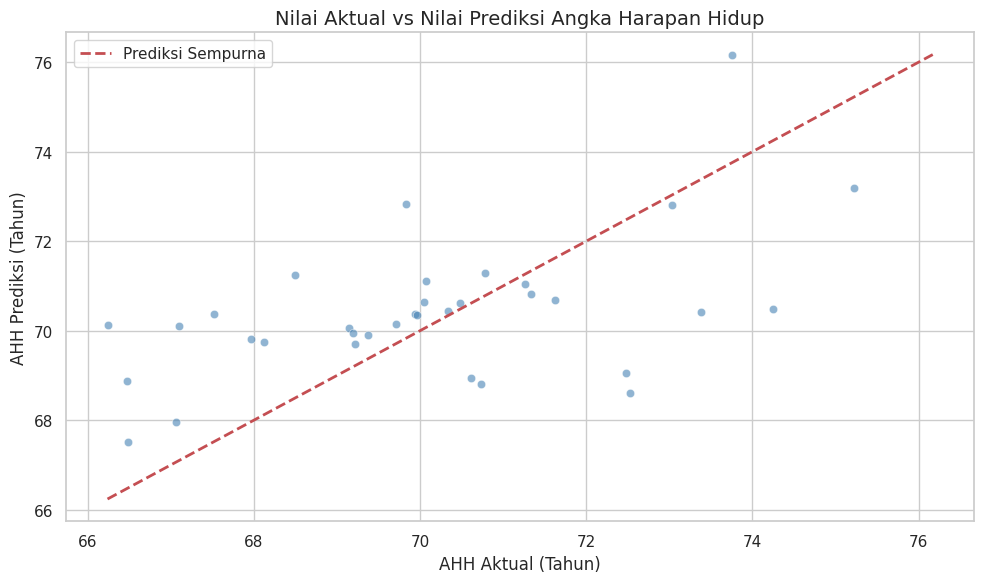

In [74]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Nilai Aktual vs Nilai Prediksi Angka Harapan Hidup', fontsize=14)
plt.xlabel('AHH Aktual (Tahun)', fontsize=12)
plt.ylabel('AHH Prediksi (Tahun)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

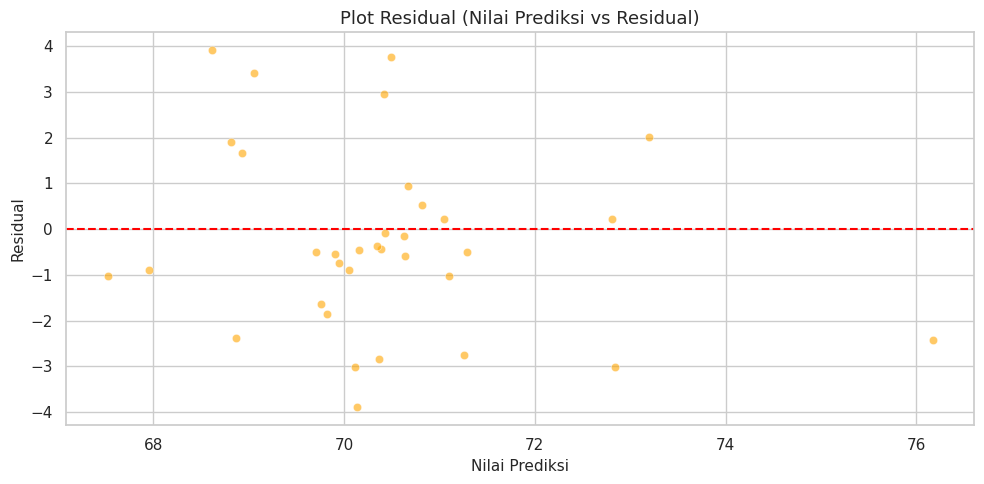

In [75]:
residual = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residual, alpha=0.6, color='orange', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Plot Residual (Nilai Prediksi vs Residual)', fontsize=13)
plt.xlabel('Nilai Prediksi', fontsize=11)
plt.ylabel('Residual', fontsize=11)
plt.tight_layout()
plt.show()

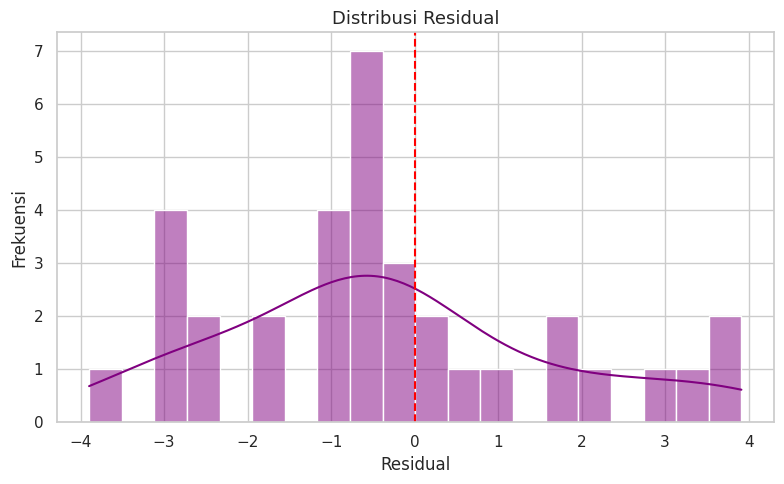

In [76]:
# VISUALISASI 3: Distribusi Residual
# Distribusi residual yang mendekati normal menunjukkan asumsi linearitas terpenuhi
plt.figure(figsize=(8, 5))
sns.histplot(residual, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribusi Residual', fontsize=13)
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

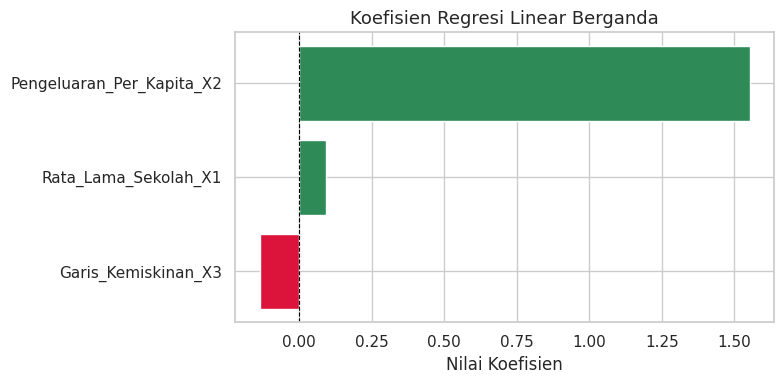

Interpretasi:
- Koefisien positif (hijau) → variabel meningkatkan Angka Harapan Hidup
- Koefisien negatif (merah) → variabel menurunkan Angka Harapan Hidup


In [77]:
koef_df = pd.DataFrame({
    'Variabel': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['crimson' if k < 0 else 'seagreen' for k in koef_df['Koefisien']]
plt.barh(koef_df['Variabel'], koef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Regresi Linear Berganda', fontsize=13)
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Koefisien positif (hijau) → variabel meningkatkan Angka Harapan Hidup")
print("- Koefisien negatif (merah) → variabel menurunkan Angka Harapan Hidup")

#  Evaluasi Model

Evaluasi model dilakukan untuk mengukur seberapa baik model dalam memprediksi Angka Harapan Hidup. Metrik yang digunakan:

| Metrik | Keterangan |
| ------ | ----------- |
| MAE    | Mean Absolute Error — rata-rata kesalahan absolut antara nilai aktual dan prediksi |
| MSE    | Mean Squared Error — rata-rata kuadrat kesalahan; memberi hukuman lebih pada error besar |
| RMSE   | Root Mean Squared Error — akar dari MSE; mudah diinterpretasikan karena satuannya sama dengan target |
| R²     | Koefisien determinasi — proporsi variansi target yang dapat dijelaskan oleh model (0–1, semakin mendekati 1 semakin baik) |

In [78]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===")
print(f"R²   (Koefisien Determinasi) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE  (Mean Absolute Error)   : {mae:.4f}")
print(f"MSE  (Mean Squared Error)    : {mse:.4f}")
print(f"RMSE (Root MSE)              : {rmse:.4f}")

print("\n=== INTERPRETASI ===")
if r2 >= 0.7:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi Angka Harapan Hidup")
    print("dapat dijelaskan oleh variabel prediktor yang digunakan. Model CUKUP BAIK.")
elif r2 >= 0.5:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi Angka Harapan Hidup")
    print("dapat dijelaskan oleh variabel prediktor. Model CUKUP MODERAT.")
else:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi Angka Harapan Hidup")
    print("dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.")


=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===
R²   (Koefisien Determinasi) : 0.2289  (22.89%)
MAE  (Mean Absolute Error)   : 1.5779
MSE  (Mean Squared Error)    : 3.9567
RMSE (Root MSE)              : 1.9891

=== INTERPRETASI ===
Model memiliki R² = 0.23, artinya 22.9% variasi Angka Harapan Hidup
dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.


In [79]:
hasil_uji = pd.DataFrame({
    'AHH Aktual': y_test.values[:10],
    'AHH Prediksi': np.round(y_pred[:10], 2),
    'Selisih (Error)': np.abs(y_test.values[:10] - y_pred[:10]).round(2)
})

print("=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===")
print(hasil_uji.to_string(index=False))

=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===
 AHH Aktual  AHH Prediksi  Selisih (Error)
      71.26         71.05             0.21
      67.97         69.82             1.85
      66.49         67.52             1.03
      73.75         76.17             2.42
      69.22         69.71             0.49
      70.34         70.43             0.09
      69.15         70.05             0.90
      71.34         70.81             0.53
      66.24         70.14             3.90
      68.50         71.25             2.75


#  Deployment / Prediksi Data Baru

Pada tahap ini, model yang telah dilatih digunakan untuk memprediksi Angka Harapan Hidup berdasarkan input data baru dari pengguna.

In [80]:
# PREDIKSI ANGKA HARAPAN HIDUP BERDASARKAN INPUT PENGGUNA

print("=== SISTEM PREDIKSI ANGKA HARAPAN HIDUP (AHH) ===")
print("Masukkan data berikut untuk memprediksi Angka Harapan Hidup:")
print()

rata_lama_sekolah    = 9.0      # Rata-rata lama sekolah (tahun)
pengeluaran_kapita   = 10000.0  # Pengeluaran per kapita disesuaikan (ribu Rp)
garis_kemiskinan     = 500000.0 # Garis kemiskinan (Rp/kapita/bulan)

print(f"Input Data Baru:")
print(f"  Rata-Rata Lama Sekolah  : {rata_lama_sekolah} tahun")
print(f"  Pengeluaran Per Kapita  : {pengeluaran_kapita} ribu Rp")
print(f"  Garis Kemiskinan        : {garis_kemiskinan} Rp/kapita/bulan")

data_baru = pd.DataFrame([{
    'Rata_Lama_Sekolah_X1': rata_lama_sekolah,
    'Pengeluaran_Per_Kapita_X2': pengeluaran_kapita,
    'Garis_Kemiskinan_X3': garis_kemiskinan
}])

data_baru_scaled = scaler.transform(data_baru)

prediksi = model.predict(data_baru_scaled)[0]

print()
print("=" * 45)
print(f"HASIL PREDIKSI:")
print(f"  Angka Harapan Hidup (AHH) : {prediksi:.2f} tahun")
print("=" * 45)

rata_nasional = df['AHH_Y'].mean()
print(f"\nRata-rata nasional (2019-2023) : {rata_nasional:.2f} tahun")

if prediksi > rata_nasional:
    print(f"Prediksi MELEBIHI rata-rata nasional → AHH TINGGI")
else:
    print(f"Prediksi DI BAWAH rata-rata nasional → AHH RENDAH")

=== SISTEM PREDIKSI ANGKA HARAPAN HIDUP (AHH) ===
Masukkan data berikut untuk memprediksi Angka Harapan Hidup:

Input Data Baru:
  Rata-Rata Lama Sekolah  : 9.0 tahun
  Pengeluaran Per Kapita  : 10000.0 ribu Rp
  Garis Kemiskinan        : 500000.0 Rp/kapita/bulan

HASIL PREDIKSI:
  Angka Harapan Hidup (AHH) : 69.67 tahun

Rata-rata nasional (2019-2023) : 70.28 tahun
Prediksi DI BAWAH rata-rata nasional → AHH RENDAH


In [81]:
# KESIMPULAN

print("=" * 55)
print("KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA")
print("=" * 55)
print()
print("Judul:")
print("  Prediksi Angka Harapan Hidup (AHH) Berdasarkan")
print("  Rata-Rata Lama Sekolah, Pengeluaran Per Kapita,")
print("  dan Garis Kemiskinan di Provinsi Indonesia")
print("  Tahun 2019-2023")
print()
print("Variabel Prediktor (X):")
print("  1. Rata-Rata Lama Sekolah (Rata_Lama_Sekolah_X1)")
print("  2. Pengeluaran Per Kapita (Pengeluaran_Per_Kapita_X2)")
print("  3. Garis Kemiskinan (Garis_Kemiskinan_X3)")
print()
print("Variabel Target (Y):")
print("  Angka Harapan Hidup (AHH_Y)")
print()
print("Persamaan Model:")
print(f"  Y = {b0:.4f} + ({b1:.4f})×X₁ + ({b2:.4f})×X₂ + ({b3:.4f})×X₃")
print()
print("Hasil Evaluasi:")
print(f"  R²   = {r2:.4f}  → Model menjelaskan {r2*100:.2f}% variansi data")
print(f"  MAE  = {mae:.4f}  → Rata-rata kesalahan absolut")
print(f"  RMSE = {rmse:.4f}  → Ukuran error yang mudah diinterpretasikan")
print()
print("=" * 55)

KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA

Judul:
  Prediksi Angka Harapan Hidup (AHH) Berdasarkan
  Rata-Rata Lama Sekolah, Pengeluaran Per Kapita,
  dan Garis Kemiskinan di Provinsi Indonesia
  Tahun 2019-2023

Variabel Prediktor (X):
  1. Rata-Rata Lama Sekolah (Rata_Lama_Sekolah_X1)
  2. Pengeluaran Per Kapita (Pengeluaran_Per_Kapita_X2)
  3. Garis Kemiskinan (Garis_Kemiskinan_X3)

Variabel Target (Y):
  Angka Harapan Hidup (AHH_Y)

Persamaan Model:
  Y = 70.3429 + (0.0929)×X₁ + (1.5527)×X₂ + (-0.1365)×X₃

Hasil Evaluasi:
  R²   = 0.2289  → Model menjelaskan 22.89% variansi data
  MAE  = 1.5779  → Rata-rata kesalahan absolut
  RMSE = 1.9891  → Ukuran error yang mudah diinterpretasikan

